In [ ]:
import pandas as pd

# Load the core datasets
results = pd.read_csv("Formula 1 World Championship/results.csv")  
races = pd.read_csv("Formula 1 World Championship/races.csv")      
weather = pd.read_csv("weather_f1/weather_features_v4.csv")  
# STEP 1: Merge Results with Race info
df = pd.merge(results, races[['raceId', 'year', 'name', 'date']], on='raceId')

# STEP 2: Merge with Weather data
df_final = pd.merge(df, weather, on=['year', 'round'], how='left')

# STEP 3: CreateTarget Variable
df_final['is_winner'] = df_final['positionOrder'].apply(lambda x: 1 if x == 1 else 0)

df_model = df_final[['year', 'grid', 'is_winner', 'air_temp', 'track_temp', 'raining']]

print(df_model.head())

KeyError: 'round'

In [ ]:
print("Results Columns:", results.columns)
print("Races Columns:", races.columns)
print("Weather Columns:", weather.columns)

Results Columns: Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId'],
      dtype='object')
Races Columns: Index(['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url',
       'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time',
       'quali_date', 'quali_time', 'sprint_date', 'sprint_time'],
      dtype='object')
Weather Columns: Index(['temperature', 'precipitation', 'windspeed', 'round', 'name',
       'datetime'],
      dtype='object')


In [ ]:

df = pd.merge(results, races[['raceId', 'year', 'round', 'name']], on='raceId')
df_final = pd.merge(df, weather, on=['year', 'round'], how='left')

print("Success! Merged columns are:", df_final.columns)

Success! Merged columns are: Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'name_x', 'temperature',
       'precipitation', 'windspeed', 'name_y', 'datetime', 'date_time_column',
       'month'],
      dtype='object')


In [ ]:
import pandas as pd

# Convert the column to a "Datetime" format
weather['date_time_column'] = pd.to_datetime(weather['datetime'])

weather['year'] = weather['date_time_column'].dt.year
weather['month'] = weather['date_time_column'].dt.month

print(weather[['date_time_column', 'year', 'month']].head())

     date_time_column  year  month
0 1950-05-13 12:00:00  1950      5
1 1950-05-21 12:00:00  1950      5
2 1950-05-30 14:00:00  1950      5
3 1950-06-04 14:00:00  1950      6
4 1950-06-18 12:00:00  1950      6


In [ ]:
# 1. Convert the 'date' column to a proper date format
df_final['date'] = pd.to_datetime(df_final['date'])

# 2. Extract the 'hour' from the time column (if it's a string like "14:00:00")
df_final['hour'] = pd.to_datetime(df_final['time'], errors='coerce').dt.hour

# 3. Handle the "Rain" column
df_final['is_rainy'] = df_final['weather_condition'].apply(lambda x: 1 if 'rain' in str(x).lower() else 0)

KeyError: 'date'

In [ ]:
import pandas as pd

# 1. Load your files (Ensure these names match your saved files exactly!)
results = pd.read_csv("Formula 1 World Championship/results.csv")  # Race finish positions
races = pd.read_csv("Formula 1 World Championship/races.csv")      # Track names, dates, years
weather = pd.read_csv("weather_f1/weather_features_v4.csv") 

# 2. Merge Results and Races first to get 'year' and 'round' into the results
df = pd.merge(results, races[['raceId', 'year', 'round', 'name', 'date', 'time']], on='raceId')

if 'season' in weather.columns:
    weather = weather.rename(columns={'season': 'year'})
    
df_final = pd.merge(df, weather, on=['year', 'round'], how='left')
print(f"Total rows in merged data: {len(df_final)}")
print("Columns now available:", df_final.columns.tolist())
df_final.head()


KeyError: 'year'

In [ ]:
print("Is 'year' in df?", 'year' in df.columns)
print("Is 'year' in weather?", 'year' in weather.columns)
print("Columns in weather are actually:", weather.columns.tolist())

Is 'year' in df? True
Is 'year' in weather? False
Columns in weather are actually: ['temperature', 'precipitation', 'windspeed', 'round', 'name', 'datetime']


In [ ]:
import pandas as pd

weather['datetime'] = pd.to_datetime(weather['datetime'])

weather['year'] = weather['datetime'].dt.year
weather['month'] = weather['datetime'].dt.month

print("Updated Weather Columns:", weather.columns.tolist())
display(weather[['datetime', 'year', 'month']].head())

Updated Weather Columns: ['temperature', 'precipitation', 'windspeed', 'round', 'name', 'datetime', 'year', 'month']


,datetime,year,month
0,1950-05-13 12:00:00,1950,5
1,1950-05-21 12:00:00,1950,5
2,1950-05-30 14:00:00,1950,5
3,1950-06-04 14:00:00,1950,6
4,1950-06-18 12:00:00,1950,6


In [ ]:
df_final = pd.merge(df, weather, on=['year', 'round'], how='left')

print("Merge Successful!")
print(f"Final Data Shape: {df_final.shape}")

Merge Successful!
Final Data Shape: (26759, 29)


In [ ]:
weather['year'] = weather['datetime'].dt.year
weather['month'] = weather['datetime'].dt.month

weather.to_csv("weather_f1/weather_features_v4.csv", index=False)

print("Old file updated! 'weather_features_v4.csv' now contains year and month.")

Old file updated! 'weather_features_v4.csv' now contains year and month.


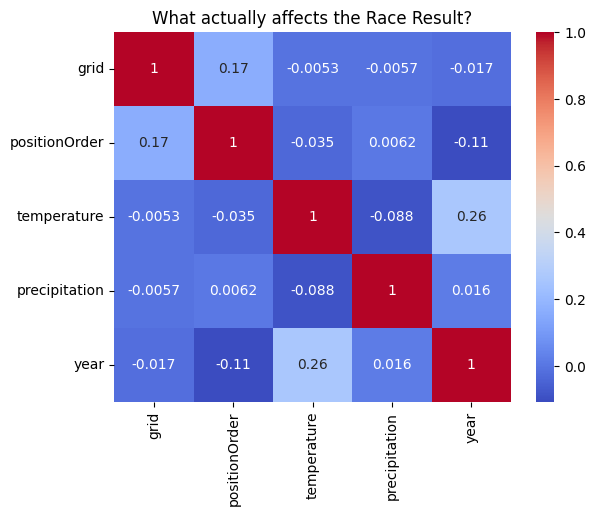

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_columns = ['grid', 'positionOrder', 'temperature', 'precipitation', 'year']
correlation = df_final[corr_columns].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("What actually affects the Race Result?")
plt.show()

In [ ]:
print(df_final.isnull().sum())

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time_x             0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
year               0
round              0
name_x             0
date               0
time_y             0
temperature        0
precipitation      0
windspeed          0
name_y             0
datetime           0
month              0
dtype: int64


In [ ]:
missing_data = df_final[['temperature', 'precipitation', 'grid']].isnull().sum()
print("Missing values per column:\n", missing_data)


Missing values per column:
 temperature      0
precipitation    0
grid             0
dtype: int64


In [ ]:
df_final['is_rainy'] = (df_final['precipitation'] > 0).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

df_final['is_winner'] = (df_final['positionOrder'] == 1).astype(int)

X = df_final[['grid', 'temperature', 'is_rainy', 'constructorId']]
y = df_final['is_winner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} rows. Testing on {len(X_test)} rows.")

Training on 21407 rows. Testing on 5352 rows.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
# 2. Training (The AI is now 'studying' the historical patterns)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      5124
           1       0.32      0.26      0.29       228

    accuracy                           0.95      5352
   macro avg       0.65      0.62      0.63      5352
weighted avg       0.94      0.95      0.94      5352



In [ ]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

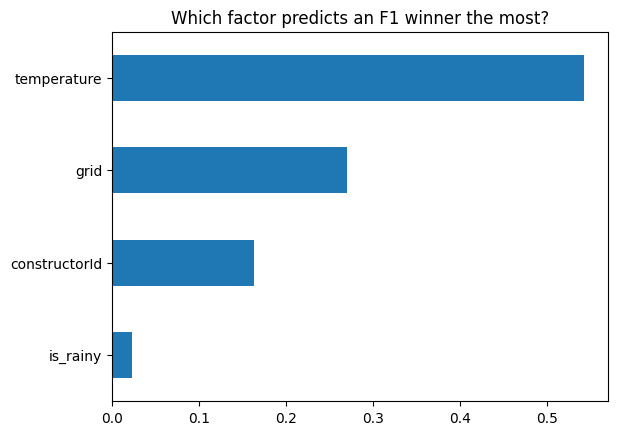

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance levels from the model
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Which factor predicts an F1 winner the most?")
plt.show()

<Axes: >

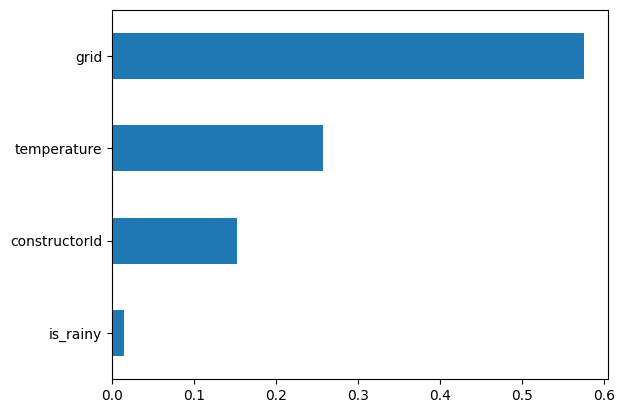

In [ ]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')

In [ ]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Re-initialize
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Re-train (This is the 'Fitting' part)
model.fit(X_train, y_train) 

print("Model is now fitted and ready to predict!")

Model is now fitted and ready to predict!


In [ ]:
import pandas as pd

def predict_race_winner(grid_pos, temp, rainy, constructor_id):
    # 1. Create a mini-dataframe with your inputs
    input_data = pd.DataFrame([[grid_pos, temp, int(rainy), constructor_id]], 
                               columns=['grid', 'temperature', 'is_rainy', 'constructorId'])
    
    # 2. Get the prediction (0 or 1)
    prediction = model.predict(input_data)[0]
    
    # 3. Get the probability (e.g., 0.85 chance of winning)
    probability = model.predict_proba(input_data)[0][1]
    
    if prediction == 1:
        return f"🏆 Predicted WINNER! (Confidence: {probability*100:.1f}%)"
    else:
        return f"❌ Likely to lose. (Win Probability: {probability*100:.1f}%)"

print(predict_race_winner(grid_pos=1, temp=30, rainy=False, constructor_id=1))

🏆 Predicted WINNER! (Confidence: 56.8%)


In [ ]:
import pandas as pd

drivers = pd.read_csv("Formula 1 World Championship/drivers.csv")

X_test_with_names = X_test.copy()
X_test_with_names['driverId'] = df_final.loc[X_test.index, 'driverId']

predicted_winner_ids = X_test_with_names[y_pred == 1]['driverId']
winner_names = drivers[drivers['driverId'].isin(predicted_winner_ids)]

print("--- The AI's Predicted Winners for the Test Set ---")
print(winner_names[['forename', 'surname']])

--- The AI's Predicted Winners for the Test Set ---
        forename        surname
0          Lewis       Hamilton
2           Nico        Rosberg
3       Fernando         Alonso
4         Heikki     Kovalainen
7           Kimi      Räikkönen
12        Felipe          Massa
13         David      Coulthard
16          Mark         Webber
17        Jenson         Button
19     Sebastian         Vettel
21        Rubens    Barrichello
22          Ralf     Schumacher
29       Michael     Schumacher
30          Juan  Pablo Montoya
34       Jacques     Villeneuve
54          Jean          Alesi
55         Eddie         Irvine
56          Mika       Häkkinen
76       Gerhard         Berger
94         Nigel        Mansell
101       Ayrton          Senna
104      Michele       Alboreto
116        Alain          Prost
136       Nelson         Piquet
144   Alessandro        Nannini
162         René         Arnoux
172         Elio     de Angelis
176         Keke        Rosberg
177         Alan    

In [ ]:
from sklearn.tree import export_text

# 1. Pick just ONE tree from your forest of 100
one_tree = model.estimators_[0]

# 2. Print the rules it learned
tree_rules = export_text(one_tree, feature_names=list(X.columns))
print(tree_rules[:500]) # Printing the first few rules

|--- constructorId <= 9.50
|   |--- grid <= 4.50
|   |   |--- grid <= 2.50
|   |   |   |--- grid <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- grid >  0.50
|   |   |   |   |--- temperature <= 34.50
|   |   |   |   |   |--- constructorId <= 8.00
|   |   |   |   |   |   |--- grid <= 1.50
|   |   |   |   |   |   |   |--- is_rainy <= 0.50
|   |   |   |   |   |   |   |   |--- temperature <= 9.20
|   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- temper


In [ ]:
print(predict_race_winner(grid_pos=20, temp=30, rainy=False, constructor_id=1))

❌ Likely to lose. (Win Probability: 0.0%)


In [ ]:
df_modern = df_final[df_final['year'] >= 2014].copy()

print(f"Old Dataset Size: {len(df_final)} rows")
print(f"Modern Era Size (2014-Present): {len(df_modern)} rows")
print("Your model is now focused on Hybrid Era physics!")

Old Dataset Size: 26759 rows
Modern Era Size (2014-Present): 4626 rows
Your model is now focused on Hybrid Era physics!


In [ ]:
# Create a weight column: newer races get higher weight
max_year = df_modern['year'].max()
df_modern['sample_weight'] = df_modern['year'].apply(lambda x: 1.0 if x == max_year else 0.5)


In [ ]:

df_modern = pd.merge(df_modern, races[['raceId', 'circuitId']], on='raceId', how='left')

X = df_modern[['grid', 'temperature', 'is_rainy', 'constructorId', 'circuitId']]

print("Success! 'circuitId' is now part of your features.")
print(X.head())

Success! 'circuitId' is now part of your features.
   grid  temperature  is_rainy  constructorId  circuitId
0     3         19.6         0            131          1
1     4         19.6         0              1          1
2    10         19.6         0              1          1
3     5         19.6         0              6          1
4    15         19.6         0              3          1


In [ ]:
df_modern['track_history'] = df_modern.groupby(['driverId', 'circuitId'])['positionOrder'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
)

df_modern['track_history'] = df_modern['track_history'].fillna(10)

In [ ]:
import joblib

joblib.dump(model, 'd:/F1 prediction/f1_model.pkl')

print("Model saved successfully! Now your app.py can 'see' it.")

Model saved successfully! Now your app.py can 'see' it.


In [ ]:
print(list(X_train.columns))

['grid', 'temperature', 'is_rainy', 'constructorId']


In [ ]:
X = df_modern[['grid', 'temperature', 'is_rainy', 'constructorId', 'circuitId']]
y = df_modern['is_winner']

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X, y)
import joblib
joblib.dump(model, 'f1_model.pkl')

['f1_model.pkl']

In [ ]:
model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10,        # Limiting depth prevents 'Hard Rules'
    class_weight='balanced_subsample', 
    random_state=42
)
model.fit(X_train, y_train)
joblib.dump(model, 'f1_model.pkl')

['f1_model.pkl']

In [ ]:
print(model.feature_names_in_)

['grid' 'temperature' 'is_rainy' 'constructorId']


In [ ]:
features_list = ['grid', 'temperature', 'is_rainy', 'constructorId', 'circuitId']
X = df_modern[features_list]
y = df_modern['is_winner']
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X, y)
import joblib
joblib.dump(model, 'f1_model.pkl')

print("Success! New 5-feature model saved. Features:", model.feature_names_in_)

Success! New 5-feature model saved. Features: ['grid' 'temperature' 'is_rainy' 'constructorId' 'circuitId']


In [ ]:
# 'balanced' helps, but 'balanced_subsample' is even better for rare wins
model = RandomForestClassifier(
    n_estimators=100, 
    class_weight={0: 1, 1: 25}, 
    random_state=42
)
model.fit(X_train, y_train)
joblib.dump(model, 'f1_model.pkl')

['f1_model.pkl']

In [ ]:
import joblib
from sklearn.ensemble import RandomForestClassifier

features_list = ['grid', 'temperature', 'is_rainy', 'constructorId', 'circuitId', 'driverId']

X = df_modern[features_list]
y = df_modern['is_winner']

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X, y)

joblib.dump(model, 'f1_model.pkl')
print("Model Ready with 6 Features: ", model.feature_names_in_)

Model Ready with 6 Features:  ['grid' 'temperature' 'is_rainy' 'constructorId' 'circuitId' 'driverId']


In [ ]:
import pandas as pd

df_races = pd.read_csv('Formula 1 World Championship/races.csv')
df_circuits = pd.read_csv('Formula 1 World Championship/circuits.csv')

modern_races = df_races[(df_races['year'] >= 2020) & (df_races['year'] <= 2026)]

modern_circuit_ids = modern_races['circuitId'].unique()
modern_circuits = df_circuits[df_circuits['circuitId'].isin(modern_circuit_ids)]
pd.set_option('display.max_rows', None)
print(modern_circuits[['name', 'circuitId']].sort_values(by='name'))

                                    name  circuitId
0         Albert Park Grand Prix Circuit          1
20         Autodromo Enzo e Dino Ferrari         21
73  Autodromo Internazionale del Mugello         76
13          Autodromo Nazionale di Monza         14
31          Autódromo Hermanos Rodríguez         32
72    Autódromo Internacional do Algarve         75
17            Autódromo José Carlos Pace         18
2          Bahrain International Circuit          3
71                     Baku City Circuit         73
6              Circuit Gilles Villeneuve          7
38                Circuit Park Zandvoort         39
33                   Circuit Paul Ricard         34
3         Circuit de Barcelona-Catalunya          4
5                      Circuit de Monaco          6
12          Circuit de Spa-Francorchamps         13
68               Circuit of the Americas         69
10                           Hungaroring         11
4                          Istanbul Park          5
74          